In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Нормальное распределение

Импортируем класс нормального распределения. Параметры инициализации - `loc` (мат ожидание) и `scale` (стандартное отклонение).

In [22]:
from scipy.stats import norm, binom, t, ttest_1samp

In [23]:
stand_norm = norm(loc=0, scale=1)

In [24]:
print(f'Cumulative distribution function for x=2: {stand_norm.cdf(x=2)}')  
print(f'Cumulative distribution function for x=2 and for x=-1: {stand_norm.cdf(x=[2, -1])}') #можно передавать массивы
print(f'Quantile 0.95: {stand_norm.ppf(0.95)}') #percent point function 
print(f'Probability density function for x=0: {stand_norm.pdf(x=0)}') 

Cumulative distribution function for x=2: 0.9772498680518208
Cumulative distribution function for x=2 and for x=-1: [0.97724987 0.15865525]
Quantile 0.95: 1.6448536269514722
Probability density function for x=0: 0.3989422804014327


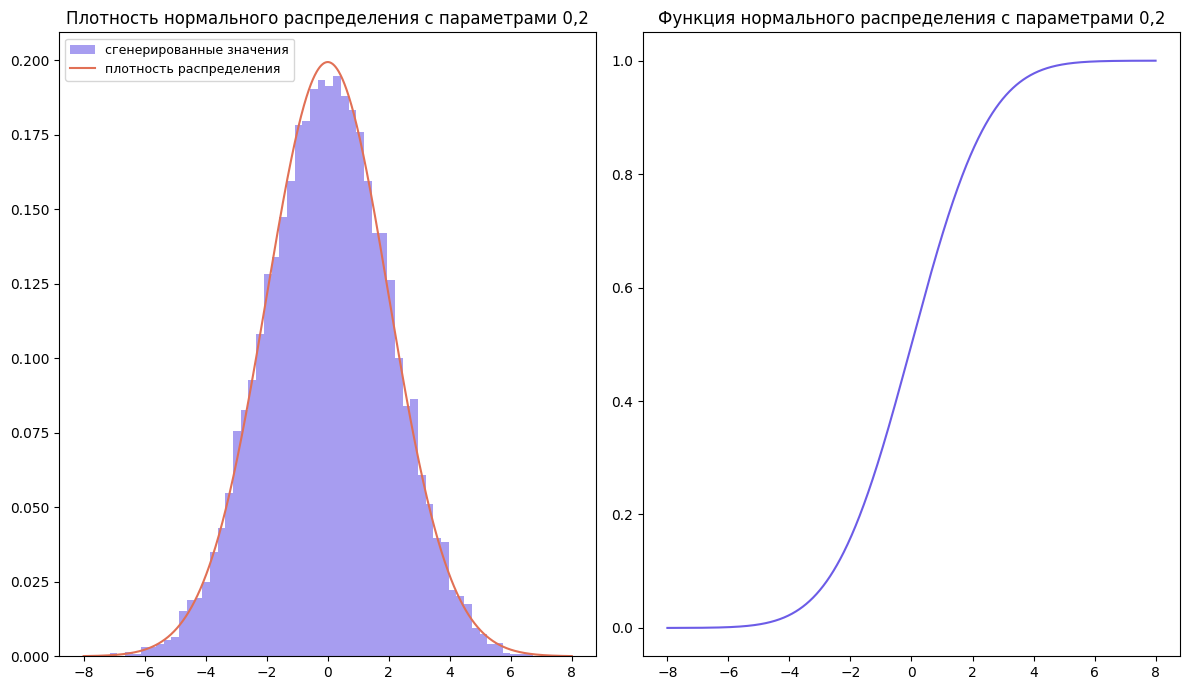

In [25]:
norm_dist = norm(0, 2)
x = np.linspace(-8, 8, 1000)

pdf = norm_dist.pdf(x)
cdf = norm_dist.cdf(x)

sample = norm_dist.rvs(10000)

plt.figure(figsize=(12,7))
plt.subplot(1, 2, 1)
plt.title('Плотность нормального распределения с параметрами 0,2', fontsize=12)
plt.hist(sample, bins='auto', density=True, alpha=0.6, label='сгенерированные значения', color='#6C5CE7')
plt.plot(x, pdf, label='плотность распределения', color='#E17055')
plt.legend(loc='upper left', fontsize=9)

plt.subplot(1, 2, 2)
plt.title('Функция нормального распределения с параметрами 0,2', fontsize=12)
plt.plot(x, cdf, '#6C5CE7')

plt.tight_layout()
plt.show()

# Вычисление p-value для нормального распределения

Возьмем сперва реализацию для биномиального распределения. 

In [26]:
def pvalue_binom(n, mu, q):
    '''
    Вычисление p-value для одностороннего теста (биномиальное распределение)
    ---------------------------------------------------------
    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    q - стастика, полученная в ходе эксперимента
    
    '''

    binom_h0 = binom(n, mu)
    return 1 - binom_h0.cdf(q -1)

In [27]:
pvalue_binom_dist = pvalue_binom(30, 0.5, 19)
print(f'Pvalue, полученное из приближения биномиальным распределением: {pvalue_binom_dist}')

Pvalue, полученное из приближения биномиальным распределением: 0.10024421103298664


In [28]:
def pvalue_normal(n, mu_0, t):
    '''
    Функция, считающая pvalue для статистики t для нормального распределения

    ---------------------------------
    Принимает на вход
    n - размер выборки
    mu_0 - предполагаемое реальное среднее
    t - статистика, полученная входе эскперимента

    На выходе: pvalue для статистики
    '''

    sum_mu = n * mu_0
    sum_variance = n * mu_0 * (1-mu_0)
    sum_std = np.sqrt(sum_variance)

    return 1 - norm(sum_mu, sum_std).cdf(t)

In [29]:
pvalue_norm_dist = pvalue_normal(30, 0.5, 19)
print(f'Pvalue, полученное из приближения нормальным распределением: {pvalue_norm_dist}')

Pvalue, полученное из приближения нормальным распределением: 0.07206351740800765


Значения не совпали с тем, что было для биномиального. Выборка недостаточно большая, чтобы ее можно было корректно приблизить нормальным распределением. 

In [30]:
n = 3000
mu_0  = 0.5
q = 1544

pvalue_binom_dist = pvalue_binom(n, mu_0, q)
print(f'Pvalue, полученное из приближения биномиальным распределением: {pvalue_binom_dist}')
pvalue_norm_dist = pvalue_normal(n, mu_0, q)
print(f'Pvalue, полученное из приближения нормальным распределением: {pvalue_norm_dist}')

Pvalue, полученное из приближения биномиальным распределением: 0.056090883742957565
Pvalue, полученное из приближения нормальным распределением: 0.05406527265575145


# Z-критерий Фишера

Статистика $Z(X) = \sqrt{n} \cdot \frac{\hat{X} - \mu_0}{\sqrt{\sigma^2}}$

In [31]:
def z_criterion_pvalue(sample_mean, sample_size, mu0, variance):
    Z_statistic = np.sqrt(sample_size) * (sample_mean - mu0) / np.sqrt(variance)
    return 1 - norm().cdf(Z_statistic)

In [32]:
n = 30
q = 19
mu0 = 0.5
variance = mu0 * (1 - mu0)

pvalue_norm_1 = z_criterion_pvalue(sample_mean=q/n, sample_size=n, mu0=mu0, variance=variance)
print(f'Z-criteria p-value: {pvalue_norm_1}')

Z-criteria p-value: 0.07206351740800765


# Неизвестная дисперсия

In [33]:
X = np.array([5.9, 2.45, 3.32, 6.88, 3.09, 8.13, 3.76])

print(f'Оценка sigma^2: {X.var(ddof=1)}') #delta degree of freedom - количество степеней свободы

Оценка sigma^2: 4.723866666666668


In [34]:
def sample_statistics_dist(n_experiments, statistic_function, sample_size, sample_distr):
    '''
    Функция, возвращающая выборку статистик на основе введенных параметров

    ----------------
    n_experiments - количество проведенных экспериментов
    statistic_function - преобразование, которое проводится над выборкой
    sample_size - размер выборки
    sample_dist - предполагаемое распределение, из которого была получена выборка

    Возвращает список со статистиками
    '''
    statistic_sample = []

    for _ in range(n_experiments):
        sample = sample_distr.rvs(sample_size)
        statistic = statistic_function(sample)

        statistic_sample.append(statistic)
    
    return statistic_sample

In [35]:
np.random.seed(13)

sample_size = len(X)
n = 10000
sample_distr = norm(5,3)

T_X = lambda sample: np.sqrt(sample_size) * (np.mean(sample) - sample_distr.mean())  / np.std(sample, ddof=1)
Z_X = lambda sample: np.sqrt(sample_size) * (np.mean(sample) - sample_distr.mean())  / sample_distr.std()

samples = {
    'T(X)': sample_statistics_dist(n_experiments=n, statistic_function=T_X, sample_size=sample_size, sample_distr=sample_distr),
    'Z(X)': sample_statistics_dist(n_experiments=n, statistic_function=Z_X, sample_size=sample_size, sample_distr=sample_distr)
}

Можем убедиться, что на самом деле t-статистика распределена не совсем по стандартному нормальному распределению. По графику можем видеть, что хвосты распределения более тяжелые по сравнению с нормальным распределением. 

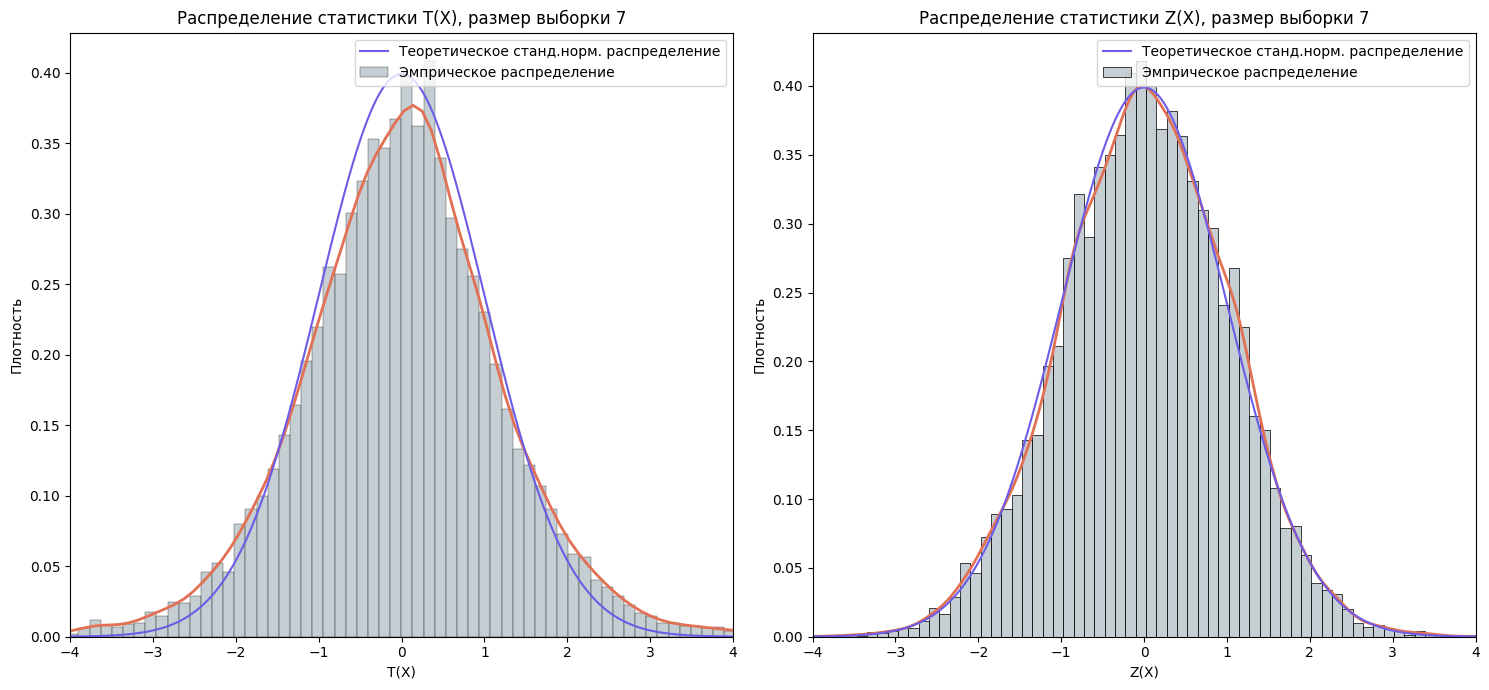

In [36]:
plt.figure(figsize=(15,7))

for i, name in enumerate(['T(X)', 'Z(X)']):
    plt.subplot(1, 2, i + 1)
    current_sample = samples[name]
    x = np.linspace(-4, 4, 1000)
    plt.title(f'Распределение статистики {name}, размер выборки {sample_size}')
    sns.histplot(current_sample, kde=False, label='Эмприческое распределение', stat='density', color='#B2BEC3')
    sns.kdeplot(current_sample, color='#E17055', linewidth=2)
    plt.plot(x, norm(0,1).pdf(x),  label='Теоретическое станд.норм. распределение', color='#6C5CE7')
    plt.xlabel(f'{name}')
    plt.ylabel('Плотность')
    plt.legend(fontsize=10, loc='upper right')
    plt.xlim((-4, 4))

plt.tight_layout()
plt.show()


Нарисуем, как распределена выборочная дисперсия. 

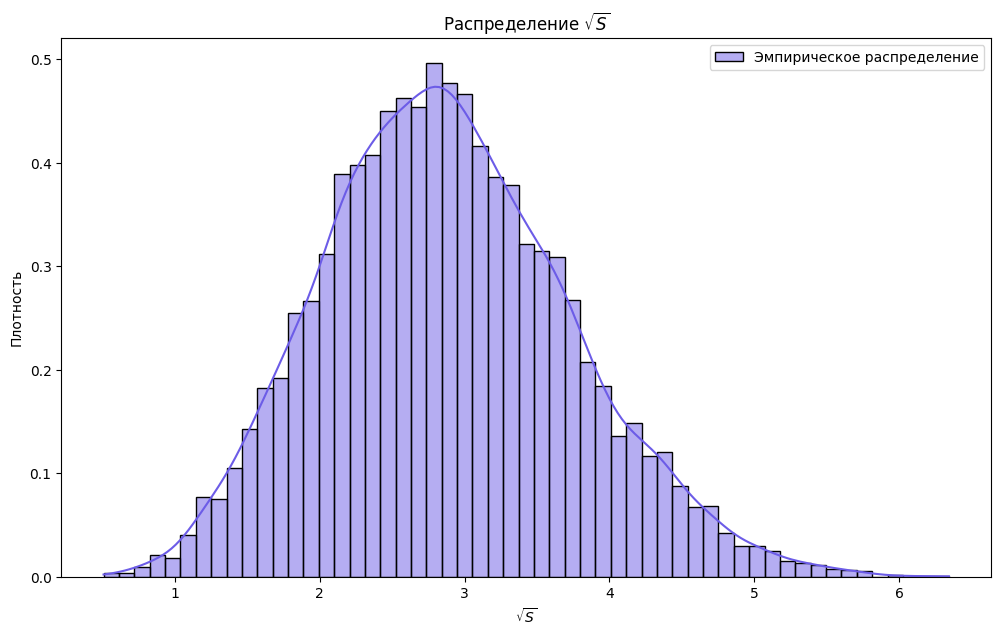

In [37]:
np.random.seed(8)

s2 = lambda sample: np.std(sample, ddof=1)
s2_sample = sample_statistics_dist(n_experiments=n, statistic_function=s2, sample_size=sample_size, sample_distr=sample_distr)

plt.figure(figsize=(12,7))
plt.title('Распределение $\\sqrt{S}$')
sns.histplot(s2_sample, stat='density', kde=True, label='Эмпирическое распределение', color='#6C5CE7')
plt.legend()
plt.xlabel('$\\sqrt{S}$')
plt.ylabel('Плотность')
plt.show()

# T-test

In [38]:
t_test = np.sqrt(len(X)) * (np.mean(X) - 7) / np.std(X, ddof=1)
t_test

np.float64(-2.6902489974105612)

In [39]:
p_value = t(7-1).cdf(t_test)
p_value

np.float64(0.01802035750889251)

In [40]:
ttest_1samp(X, popmean=7, alternative='less')

TtestResult(statistic=np.float64(-2.690248997410561), pvalue=np.float64(0.01802035750889251), df=np.int64(6))

p-value меньше, чем 0.05, отвергаем нулевую гипотезу о равенства среднего 7 в пользу того, что среднее меньше 7. 

Можем получить более подробную информацию, рассчитав 95% доверительный интервал. 

In [50]:
left_bound, right_bound = t.interval(confidence=0.95, loc=np.mean(X), df=len(X)-1, scale=np.sqrt(np.var(X, ddof=1)/7))
print(f'CI [{left_bound:.2f} ; {right_bound:.2f}]')

CI [2.78 ; 6.80]


In [51]:
from scipy.stats import sem
left_bound, right_bound = t.interval(confidence=0.95, loc=np.mean(X), df=len(X)-1, scale=sem(X))
print(f'CI [{left_bound:.2f} ; {right_bound:.2f}]')

CI [2.78 ; 6.80]


Как и ожидалось, 7 не входит в интервал.

# AB-тест. Двувыборочный T-тест.

In [60]:
from scipy.stats import expon, ttest_ind
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW
np.random.seed(10)

X = expon(scale=1100).rvs(1000)
Y = norm(980,30).rvs(1000)

ttest_ind(X, Y, equal_var=False, alternative='greater').pvalue

np.float64(0.003098390214938444)

In [61]:
cm = CompareMeans(DescrStatsW(X), DescrStatsW(Y))
print(cm.tconfint_diff(usevar='unequal'))


(np.float64(26.38785905277318), np.float64(159.04887194953284))
